In [33]:
# Импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

In [34]:
# Загрузка данных
data = pd.read_csv('train.csv.xls')
data.info()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [35]:
# Удаление пропусков и категориальных переменных
data_cleaned = data.select_dtypes(exclude=['object'])
data_cleaned = data_cleaned.dropna()
print(data_cleaned.info())

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        714 non-null    int64  
 5   Parch        714 non-null    int64  
 6   Fare         714 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 44.6 KB
None


### Обучение модели и оценка качества

In [36]:
# Определение признаков (X) и целевой переменной (y)
X = data_cleaned.drop('Survived', axis=1)
y = data_cleaned['Survived']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Инициализация и обучение модели логистической регрессии
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

print("Модель успешно обучена.")

Модель успешно обучена.


ROC AUC score: 0.7087


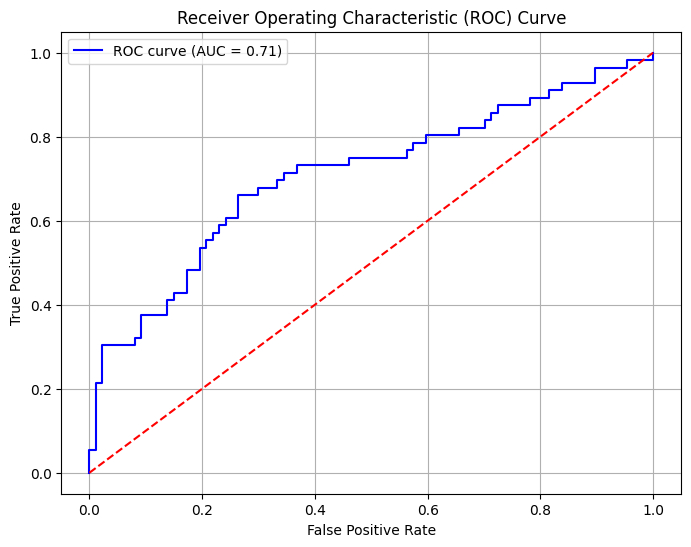

In [37]:
# Прогнозирование вероятностей на тестовой выборке
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Расчет ROC AUC метрики
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC score: {roc_auc:.4f}")

# Построение ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

### Повторная загрузка данных и удаление нерелевантных признаков

In [38]:
# Повторная загрузка данных
data_full = pd.read_csv('train.csv.xls')
print(data_full.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Теперь удалим признаки, которые логически не нужны для построения модели:

*   **PassengerId:** Это просто уникальный идентификатор пассажира и не содержит информации, полезной для прогнозирования выживаемости.
*   **Name:** Имя пассажира само по себе не является предсказывающим фактором.
*   **Ticket:** Номер билета — это обычно сложная строка без очевидной числовой или категориальной связи с выживаемостью.
*   **Cabin:** Этот столбец имеет очень много пропущенных значений (более 77%).

In [39]:
# Удаление нерелевантных признаков
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
data_processed = data_full.drop(columns=columns_to_drop)
print(data_processed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None


### Анализ и заполнение пропущенных значений

In [40]:
# Проверка наличия пропущенных значений
missing_values = data_processed.isnull().sum()
missing_percentage = (data_processed.isnull().sum() / len(data_processed)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

print("Пропущенные значения в данных:")
display(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False))

Пропущенные значения в данных:


,Missing Count,Missing Percentage
Age,177,19.865320
Embarked,2,0.224467


a) Посчитаем, какой процент данных будет потерян, если просто удалить пропуски.

In [41]:
initial_rows = len(data_processed)
data_after_dropna = data_processed.dropna()
remaining_rows = len(data_after_dropna)

percentage_lost = ((initial_rows - remaining_rows) / initial_rows) * 100

print(f"Изначальное количество строк: {initial_rows}")
print(f"Количество строк после удаления пропусков: {remaining_rows}")
print(f"Процент потерянных данных при удалении пропусков: {percentage_lost:.2f}%")

Изначальное количество строк: 891
Количество строк после удаления пропусков: 712
Процент потерянных данных при удалении пропусков: 20.09%


b) Заполним пропуски:

*   **Age:** Заполним медианным значением, так как возраст является числовым признаком и медиана устойчива к выбросам.
*   **Embarked:** Заполним модальным значением (наиболее частым), так как это категориальный признак.

In [42]:
# Заполнение пропусков
# Для 'Age' используем медиану
data_imputed = data_processed.copy()
data_imputed['Age'] = data_imputed['Age'].fillna(data_imputed['Age'].median())

# Для 'Embarked' используем моду
most_frequent_embarked = data_imputed['Embarked'].mode()[0]
data_imputed['Embarked'] = data_imputed['Embarked'].fillna(most_frequent_embarked)

print("Пропущенные значения успешно заполнены.")
print(data_imputed.info())

# Проверка после заполнения
print("\nПропущенные значения после заполнения:")
print(data_imputed.isnull().sum())

Пропущенные значения успешно заполнены.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
None

Пропущенные значения после заполнения:
Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


### Преобразование категориальных переменных

In [43]:
# Применение One-Hot Encoding к 'Sex' и 'Embarked'
data_encoded = pd.get_dummies(data_imputed, columns=['Sex', 'Embarked'], drop_first=True)

print("Категориальные переменные успешно преобразованы.")
print(data_encoded.info())

Категориальные переменные успешно преобразованы.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Age         891 non-null    float64
 3   SibSp       891 non-null    int64  
 4   Parch       891 non-null    int64  
 5   Fare        891 non-null    float64
 6   Sex_male    891 non-null    bool   
 7   Embarked_Q  891 non-null    bool   
 8   Embarked_S  891 non-null    bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 44.5 KB
None


### Проверка и обработка выбросов

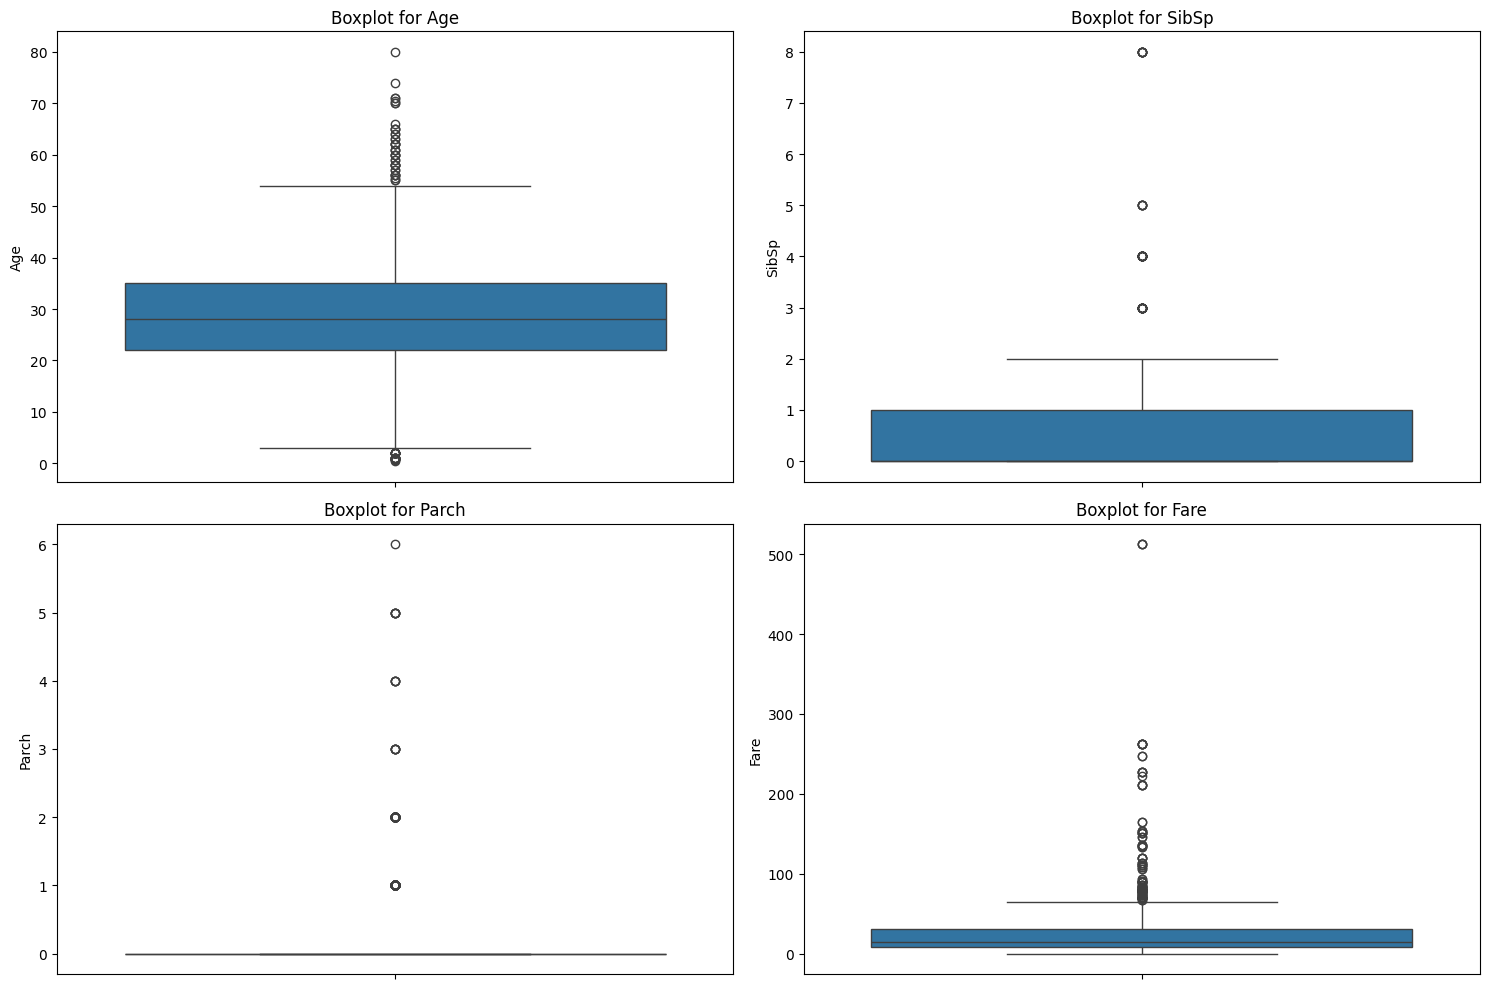

In [44]:
# Определим числовые признаки для проверки на выбросы
numerical_cols = ['Age', 'SibSp', 'Parch', 'Fare']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 2, i) # Создаем сетку 2x2 для графиков
    sns.boxplot(y=data_encoded[col])
    plt.title(f'Boxplot for {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()


Из графиков видно:

*   **Age (Возраст):** Есть несколько значений, выходящих за верхнюю границу, что является нормальным для распределения возраста (например, очень старые пассажиры).
*   **SibSp (Количество братьев/сестер или супругов на борту):** Большое количество пассажиров путешествует без SibSp, но есть и те, у кого 3, 4, 5 и даже 8. Это может быть связано с путешествиями большими семьями, но 8 выглядит как существенный выброс.
*   **Parch (Количество родителей/детей на борту):** Аналогично SibSp, большинство путешествуют без Parch, но есть и группы с 3, 4, 5 и 6.
*   **Fare (Стоимость билета):** Имеет значительное количество выбросов с высокими значениями, что логично, так как стоимость билетов может сильно варьироваться (например, для первого класса).

**Обоснование решения:**

*   Выбросы в `Age` и `Fare` (очень старые люди или дорогие билеты) могут содержать важную информацию и отражать реальные данные. Их удаление может привести к потере ценной информации.
*   Выбросы в `SibSp` и `Parch` также могут нести информацию о групповых путешествиях. Однако экстремальные значения (например, 8 SibSp) могут быть редкостью
На данный момент, учитывая, что логистическая регрессия (которую мы использовали ранее) относительно устойчива к выбросам, и чтобы не терять данные, я **не буду удалять выбросы**. В

### Визуализация данных для анализа

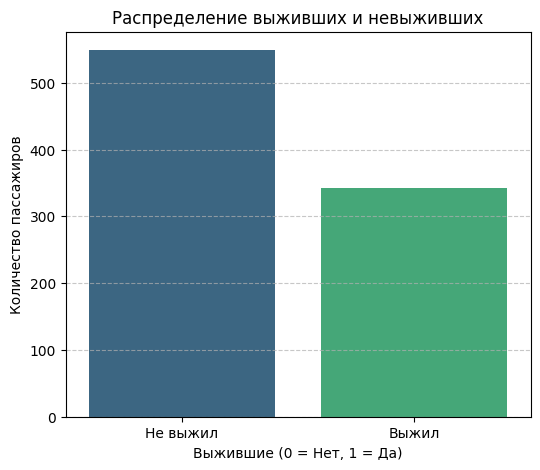

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# График 1: Распределение выживших
plt.figure(figsize=(6, 5))
sns.countplot(x='Survived', data=data_encoded, palette='viridis', hue='Survived', legend=False)
plt.title('Распределение выживших и невыживших')
plt.xlabel('Выжившие (0 = Нет, 1 = Да)')
plt.ylabel('Количество пассажиров')
plt.xticks([0, 1], ['Не выжил', 'Выжил'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Количество невыживших пассажиров значительно больше, чем выживших. Это указывает на дисбаланс классов в целевой переменной.

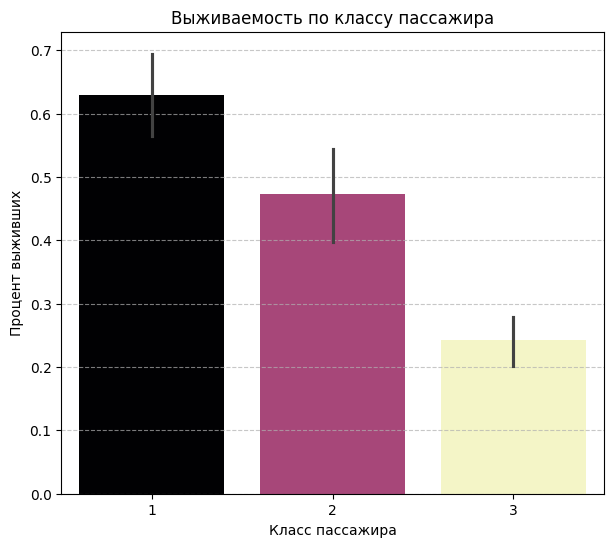

In [46]:
# График 2: Выживаемость по классу пассажира
plt.figure(figsize=(7, 6))
sns.barplot(x='Pclass', y='Survived', data=data_encoded, palette='magma', hue='Pclass', legend=False)
plt.title('Выживаемость по классу пассажира')
plt.xlabel('Класс пассажира')
plt.ylabel('Процент выживших')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Пассажиры первого класса имели значительно более высокие шансы на выживание по сравнению со вторым и, особенно, третьим классом. Это подтверждает, что 'Pclass' является очень важным признаком для предсказания выживаемости.

### Математическое преобразование признака 'Age'

Для уменьшения скошенности распределения признака 'Age' и потенциального улучшения производительности модели, применим к нему логарифмическое преобразование (в данном случае, квадратный корень, так как возраст не может быть отрицательным и логарифм может быть слишком агрессивным). Это может помочь сделать распределение более нормальным.


In [47]:
# Применение квадратного корня к признаку 'Age'
data_encoded['Age_sqrt'] = np.sqrt(data_encoded['Age'])

# Удалим оригинальный столбец 'Age', если он больше не нужен, или оставим оба.
data_encoded = data_encoded.drop('Age', axis=1)

print("Признак 'Age' преобразован в 'Age_sqrt'.")
display(data_encoded[['Age_sqrt']].head())

Признак 'Age' преобразован в 'Age_sqrt'.


,Age_sqrt
0,4.690416
1,6.164414
2,5.099020
3,5.916080
4,5.916080


In [48]:

X = data_encoded.drop(['Survived'], axis=1)
y = data_encoded['Survived']

# Разделение данных на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Данные успешно разделены на признаки, целевую переменную, а также на обучающую и тестовую выборки.")
print(f"Размер обучающей выборки X_train: {X_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
print(f"Признаки (X) после преобразования Age:")
X.head()

Данные успешно разделены на признаки, целевую переменную, а также на обучающую и тестовую выборки.
Размер обучающей выборки X_train: (712, 8)
Размер тестовой выборки X_test: (179, 8)
Признаки (X) после преобразования Age:


,Pclass,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Age_sqrt
0,3,1,0,7.2500,True,False,True,4.690416
1,1,1,0,71.2833,False,False,False,6.164414
2,3,0,0,7.9250,False,False,True,5.099020
3,1,1,0,53.1000,False,False,True,5.916080
4,3,0,0,8.0500,True,False,True,5.916080


In [49]:
#Обучение модели

In [50]:
# Инициализация и обучение модели логистической регрессии на преобразованных данных
model_transformed = LogisticRegression(solver='liblinear', random_state=42)
model_transformed.fit(X_train, y_train)

print("Модель успешно обучена на преобразованных данных.")

Модель успешно обучена на преобразованных данных.


ROC AUC score (на преобразованных данных): 0.8389


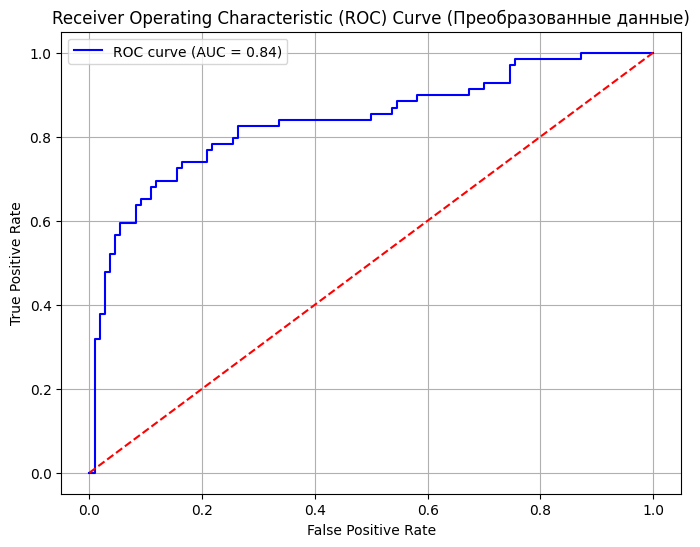

In [51]:
# Прогнозирование вероятностей на тестовой выборке
y_pred_proba_transformed = model_transformed.predict_proba(X_test)[:, 1]

# Расчет ROC AUC метрики
roc_auc_transformed = roc_auc_score(y_test, y_pred_proba_transformed)
print(f"ROC AUC score (на преобразованных данных): {roc_auc_transformed:.4f}")

# Построение ROC-кривой
fpr_transformed, tpr_transformed, thresholds_transformed = roc_curve(y_test, y_pred_proba_transformed)

plt.figure(figsize=(8, 6))
plt.plot(fpr_transformed, tpr_transformed, color='blue', label=f'ROC curve (AUC = {roc_auc_transformed:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Преобразованные данные)')
plt.legend()
plt.grid(True)
plt.show()

## Выводы по проделанной работе

**a) Краткое описание преобразований и их обоснование:**

В ходе работы были выполнены следующие ключевые преобразования данных:

1.  **Удаление нерелевантных признаков:** Мы исключили столбцы 'PassengerId', 'Name', 'Ticket' и 'Cabin'. Это было сделано потому, что 'PassengerId' и 'Name' не несут предсказательной силы для выживаемости, 'Ticket' является сложным строковым признаком без очевидной связи, а 'Cabin' имел слишком много пропущенных значений, что делало его малопригодным для использования.
2.  **Обработка пропущенных значений:**
    *   Для признака 'Age' пропуски были заполнены **медианой**. Медиана была выбрана, поскольку она более устойчива к выбросам, чем среднее, и сохраняет общую структуру распределения возраста.
    *   Для признака 'Embarked' пропуски были заполнены **модальным значением** (наиболее частым портом посадки), так как это категориальный признак, и мода является естественным выбором для его заполнения.
3.  **Кодирование категориальных признаков:** Признаки 'Sex' и 'Embarked' были преобразованы в числовой формат с помощью **One-Hot Encoding** с `drop_first=True`. Это необходимо, так как большинство моделей машинного обучения работают только с числовыми данными, а `drop_first=True` позволяет избежать мультиколлинеарности.
4.  **Математическое преобразование признака 'Age':** Для 'Age' было применено **квадратное преобразование** (вычисление квадратного корня) с созданием нового признака 'Age_sqrt'. Цель этого преобразования — уменьшить скошенность распределения 'Age' и сделать его более близким к нормальному, что может улучшить производительность линейных моделей, таких как логистическая регрессия.

**b) Сравнение метрик моделей**

*   **Первая модель, обученная на урезанных данных:** ROC AUC score составил **0.7087**.
*   **Вторая модель, обученная на преобразованных данных:** ROC AUC score составил **0.8389**.

Как видно, комплексная и продуманная предобработка данных, включая заполнение пропусков, кодирование категориальных переменных и математическое преобразование 'Age', привела к **значительному улучшению качества модели** (увеличению ROC AUC более чем на 13 процентных пунктов).

**c) Мнение о целесообразности работы с данными при построении моделей машинного обучения и об исследовании больших данных:**

Работа с данными (Data Preprocessing и Feature Engineering) является **одним из самых критически важных этапов** в процессе построения моделей машинного обучения. Как показал наш пример, даже простая логистическая регрессия может демонстрировать значительно лучшие результаты при правильной подготовке данных. Недооценка этого этапа часто приводит к получению слабых моделей.


**Нужно ли аналогичным образом исследовать и дополнять действительно большие данные?**

**Да.** Принципы исследования и предобработки данных остаются теми же, даже для очень больших объемов данных. Более того, для больших данных это становится **еще более критичным**, хотя и более сложным в реализации.
В заключение, вне зависимости от размера данных, тщательная работа с ними — это инвестиция, которая многократно окупается в виде более точных, надежных и интерпретируемых моделей машинного обучения.